# 01 — Semana 8: dataset, splits, ventaneo HU, EDA de fragmentos y MIP
**Proyecto Integrador Corte 2 — PENGWIN (fracturas pélvicas en CT)**

Este notebook es el **seguimiento del proceso** de la semana 8. No duplica lógica: toda la implementación vive en `src/*.py` y aquí solo se ejecuta, se muestran los resultados y se interpretan.

| Paso | Script | Salida |
|---|---|---|
| 1. Manifest | `src/build_manifest.py` | `data/manifest.csv` |
| 2. Diagnóstico HU | `src/check_hu_outliers.py` | consola |
| 3. Splits fijos | `src/make_splits.py` | `data/splits.json` |
| 4. Ventaneo HU | `src/hu_windowing_check.py` | `outputs/figures/hu_window_check_*.png` |
| 5. EDA de fragmentos | `src/eda_fragments.py` | `data/eda_fragments_detalle.csv`, `outputs/eda/*` |
| 6. Visualizador 1 (MIP) | `src/mip_visualizer.py` | `outputs/figures/mip_raw_*.png` |

> Uso exclusivamente académico. No es un dispositivo médico ni ha sido validado clínicamente.

In [12]:
import sys; print(sys.executable)

/Users/mariavalencia/Downloads/Proyecto 2 analitica de datos/venv/bin/python


In [13]:
# --- Setup: ubicarse en la raíz del repo (los scripts usan rutas relativas data/ y outputs/) ---
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
if "src" not in sys.path:
    sys.path.insert(0, "src")
assert Path("data/raw").exists(), "No encuentro data/raw: descarga PENGWIN de Zenodo y descomprímelo ahí (ver README)."

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from IPython.display import Image, display

SEED = 42
np.random.seed(SEED)
print("Raíz del repo:", Path.cwd())

Raíz del repo: /Users/mariavalencia/Downloads/Proyecto 2 analitica de datos


## 1. Manifest del dataset
El dataset viene en **`.mha`** (no NIfTI), así que se carga con SimpleITK. El spacing físico (mm/vóxel) se lee del header con `GetSpacing()`.

Si `data/manifest.csv` ya existe se reutiliza; para regenerarlo, borrar el archivo o poner `REGENERAR = True` (tarda ~1 min).

In [14]:
REGENERAR = False
if REGENERAR or not Path("data/manifest.csv").exists():
    %run src/build_manifest.py

manifest = pd.read_csv("data/manifest.csv", dtype={"case_id": str})
print(f"Casos: {len(manifest)} | válidos: {int(manifest['valido'].sum())}")
manifest[["case_id", "shape_z", "shape_y", "shape_x", "spacing_x_mm", "spacing_y_mm", "spacing_z_mm",
          "hu_min", "hu_max", "n_fragmentos_unicos", "valido"]].head(10)

Casos: 100 | válidos: 100


,case_id,shape_z,shape_y,shape_x,spacing_x_mm,spacing_y_mm,spacing_z_mm,hu_min,hu_max,n_fragmentos_unicos,valido
0,001,401,512,512,0.781250,0.781250,0.80000,-1023.0,2775.0,4,True
1,002,337,276,413,0.824219,0.824219,0.80000,-1023.0,4711.0,6,True
2,003,285,381,512,0.759766,0.759766,1.00000,-1023.0,16709.0,6,True
3,004,224,254,386,0.843750,0.843750,1.00000,-1418.0,4961.0,6,True
4,005,312,512,512,0.896484,0.896484,1.00000,-1023.0,4695.0,6,True
5,006,283,279,426,0.812500,0.812500,1.00000,-1023.0,1649.0,7,True
6,007,317,512,512,0.835938,0.835938,1.00000,-1023.0,19380.0,7,True
7,008,335,512,512,0.742188,0.742188,0.80000,-1024.0,1713.0,5,True
8,009,303,245,415,0.812500,0.812500,0.80000,-1023.0,1613.0,5,True
9,010,350,512,512,0.946000,0.946000,0.79895,-2048.0,7573.0,5,True


In [15]:
# Resumen de geometría: tamaño de los volúmenes y spacing
manifest[["shape_z", "shape_y", "shape_x", "spacing_x_mm", "spacing_y_mm", "spacing_z_mm"]].describe().round(3)

,shape_z,shape_y,shape_x,spacing_x_mm,spacing_y_mm,spacing_z_mm
count,100.000,100.00,100.000,100.000,100.000,100.000
mean,321.060,427.67,490.010,0.819,0.819,0.891
std,43.495,116.89,43.316,0.079,0.079,0.109
min,193.000,154.00,322.000,0.658,0.658,0.625
25%,285.750,299.50,508.000,0.781,0.781,0.800
50%,326.000,512.00,512.000,0.798,0.798,0.801
75%,350.000,512.00,512.000,0.858,0.858,1.000
max,414.000,512.00,512.000,1.220,1.220,1.250


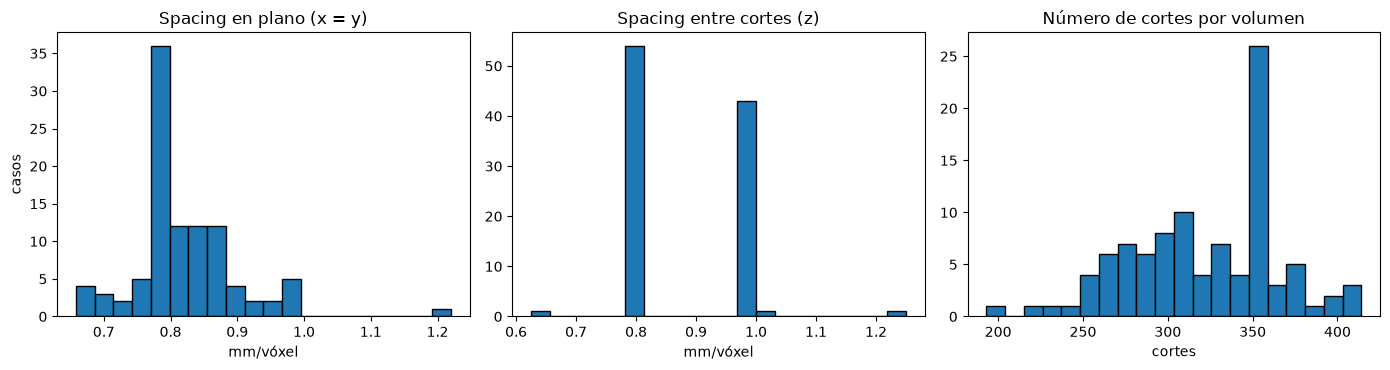

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].hist(manifest["spacing_x_mm"], bins=20, edgecolor="black")
axes[0].set(title="Spacing en plano (x = y)", xlabel="mm/vóxel", ylabel="casos")
axes[1].hist(manifest["spacing_z_mm"], bins=20, edgecolor="black")
axes[1].set(title="Spacing entre cortes (z)", xlabel="mm/vóxel")
axes[2].hist(manifest["shape_z"], bins=20, edgecolor="black")
axes[2].set(title="Número de cortes por volumen", xlabel="cortes")
plt.tight_layout(); plt.show()

**Lectura:** 100/100 casos válidos (imagen + máscara, mismas dimensiones). El spacing **no es uniforme entre casos** (≈0.66–1.22 mm en plano, 0.625–1.25 mm en z), por eso toda medida de distancia o volumen debe usar el spacing propio de cada caso y nunca reportarse en vóxeles.

## 2. Diagnóstico de valores HU
Rango esperado de un CT: aprox. -1000 (aire) a ~3000 HU (hueso cortical denso). Todo lo que se salga de ahí es padding del escáner o metal.

In [17]:
%run src/check_hu_outliers.py

Total casos válidos: 100

Top 5 casos con HU máximo más alto:
 case_id  hu_min  hu_max     hu_mean
      80 -1023.0 47685.0 -600.436101
      68 -6211.0 30445.0 -757.690200
     100 -6152.0 24970.0 -936.068190
      55 -1023.0 23354.0 -668.465611
      84 -1023.0 19419.0 -546.270047

Top 5 casos con HU mínimo más bajo:
 case_id  hu_min  hu_max      hu_mean
      68 -6211.0 30445.0  -757.690200
     100 -6152.0 24970.0  -936.068190
      51 -3376.0  9741.0  -949.747885
      96 -3193.0 13843.0  -708.974439
      74 -2913.0 15467.0 -1004.721474

Casos con valores fuera del rango esperado (-1100 a 5000 HU): 52
 case_id  hu_min  hu_max      hu_mean
       3 -1023.0 16709.0  -427.226756
       4 -1418.0  4961.0  -187.163303
       7 -1023.0 19380.0  -610.517546
      10 -2048.0  7573.0  -909.534589
      11 -2285.0  1677.0  -945.008948
      13 -1023.0 16941.0  -669.545505
      19 -2048.0  1727.0  -813.558878
      20 -2048.0  3321.0  -848.485221
      21 -2048.0  1677.0  -691.015887
     

**Lectura:** 52 casos se salen del rango típico. No son datos corruptos:
- mínimos exactos y repetidos (-2048, -3024…) = **padding** fuera del campo de reconstrucción;
- máximos muy altos (hasta 47 685 HU) = **metal**. El notebook 02 muestra que casi nunca está en el hueso pélvico: son implantes femorales y objetos externos al paciente (fijadores, elementos sobre la camilla).

**Decisión:** `clip` a **[-1024, 3000] HU** antes de cualquier normalización. El efecto del metal sobre el hueso vecino (endurecimiento de haz) y las diferencias de histograma entre casos se analizan en `02_eda_intensidades.ipynb`.

## 3. Splits fijos
Por `case_id` (nunca por corte: evita *data leakage* entre cortes del mismo paciente), estratificado por número de fragmentos y con semilla 42. El archivo versionado es la fuente de verdad, por eso aquí solo se lee.

In [18]:
with open("data/splits.json") as f:
    splits = json.load(f)
splits = {k: [str(c).zfill(3) for c in splits[k]] for k in ("train", "val", "test")}

# chequeos de integridad
todos = splits["train"] + splits["val"] + splits["test"]
assert len(todos) == len(set(todos)), "Hay casos repetidos entre splits (leakage)"
print({k: len(v) for k, v in splits.items()}, "| total:", len(todos), "| sin solapamiento ✔")

{'train': 70, 'val': 15, 'test': 15} | total: 100 | sin solapamiento ✔


## 4. Carga + ventaneo HU
`apply_hu_window` hace clip a [-1024, 3000] y luego ventana ósea C=400 / W=1800, normalizada a [0, 1]. Se prueba en un caso normal y en los dos más extremos.

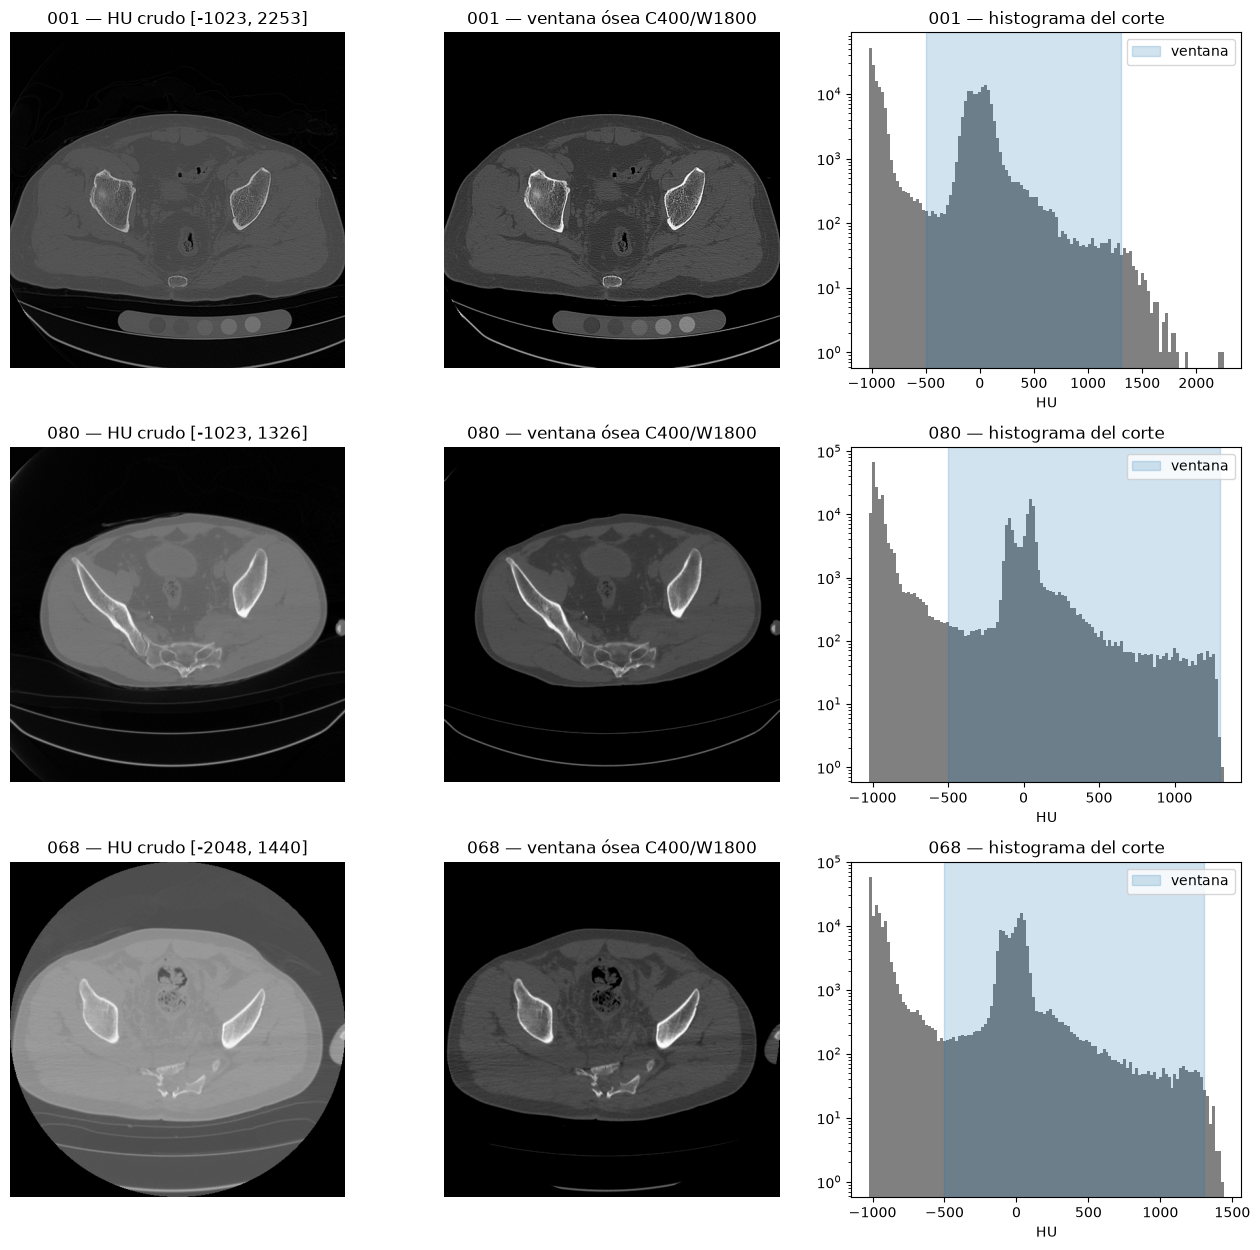

In [19]:
from hu_windowing_check import apply_hu_window, find_image_path, CLIP_MIN, CLIP_MAX, WINDOW_CENTER, WINDOW_WIDTH

CASOS = [c for c in ["001", "080", "068"] if find_image_path(c) is not None] or manifest["case_id"].head(3).tolist()

fig, axes = plt.subplots(len(CASOS), 3, figsize=(13, 4.2 * len(CASOS)), squeeze=False)
for i, cid in enumerate(CASOS):
    vol = sitk.GetArrayFromImage(sitk.ReadImage(str(find_image_path(cid))))
    corte = vol[vol.shape[0] // 2]
    win = apply_hu_window(corte, WINDOW_CENTER, WINDOW_WIDTH, CLIP_MIN, CLIP_MAX)
    axes[i, 0].imshow(corte, cmap="gray"); axes[i, 0].set_title(f"{cid} — HU crudo [{corte.min()}, {corte.max()}]")
    axes[i, 1].imshow(win, cmap="gray");   axes[i, 1].set_title(f"{cid} — ventana ósea C{WINDOW_CENTER}/W{WINDOW_WIDTH}")
    axes[i, 2].hist(np.clip(corte, CLIP_MIN, CLIP_MAX).ravel(), bins=120, log=True, color="gray")
    axes[i, 2].axvspan(WINDOW_CENTER - WINDOW_WIDTH / 2, WINDOW_CENTER + WINDOW_WIDTH / 2, alpha=0.2, color="tab:blue", label="ventana")
    axes[i, 2].set(title=f"{cid} — histograma del corte", xlabel="HU"); axes[i, 2].legend()
    for a in axes[i, :2]: a.axis("off")
plt.tight_layout(); plt.show()

## 5. EDA de fragmentos
Convención oficial de etiquetas: `0` fondo · `1–10` sacro · `11–20` coxal izquierdo · `21–30` coxal derecho.

In [20]:
REGENERAR_EDA = False
if REGENERAR_EDA or not Path("data/eda_fragments_detalle.csv").exists():
    %run src/eda_fragments.py

frag = pd.read_csv("data/eda_fragments_detalle.csv", dtype={"case_id": str})
assert frag["n_labels_desconocidos"].sum() == 0, "Hay labels fuera de la convención oficial"
pd.read_csv("outputs/eda/resumen_estadistico.csv").round(2)

,metrica,valor
0,n_casos,100.00
1,fragmentos_total_min,3.00
2,fragmentos_total_max,9.00
3,fragmentos_total_media,5.75
4,fragmentos_sacro_media,1.53
5,fragmentos_coxal_izq_media,2.15
6,fragmentos_coxal_der_media,2.07
7,casos_sin_fractura_sacro (1 fragmento),55.00
8,casos_sin_fractura_coxal_izq (1 fragmento),34.00
9,casos_sin_fractura_coxal_der (1 fragmento),36.00


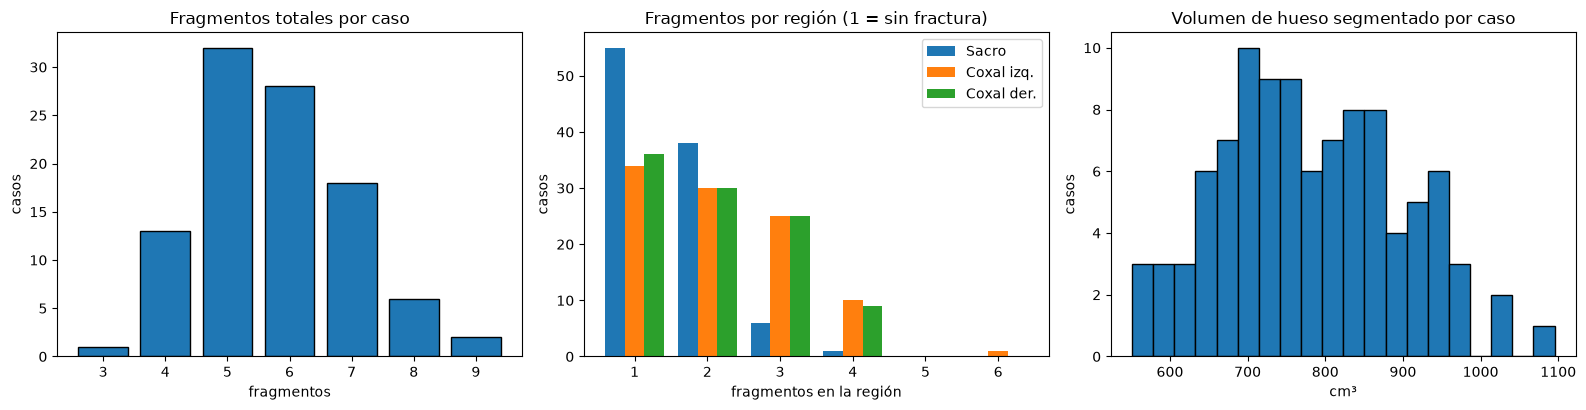

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

vc = frag["n_fragmentos_total"].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, edgecolor="black")
axes[0].set(title="Fragmentos totales por caso", xlabel="fragmentos", ylabel="casos")

cols = {"Sacro": "n_fragmentos_sacro", "Coxal izq.": "n_fragmentos_coxal_izq", "Coxal der.": "n_fragmentos_coxal_der"}
maxf = int(frag[list(cols.values())].max().max())
ancho = 0.27
for j, (nombre, c) in enumerate(cols.items()):
    cuenta = frag[c].value_counts().reindex(range(1, maxf + 1), fill_value=0)
    axes[1].bar(np.arange(1, maxf + 1) + (j - 1) * ancho, cuenta.values, width=ancho, label=nombre)
axes[1].set(title="Fragmentos por región (1 = sin fractura)", xlabel="fragmentos en la región", ylabel="casos"); axes[1].legend()

axes[2].hist(frag["volumen_hueso_total_mm3"] / 1000, bins=20, edgecolor="black")
axes[2].set(title="Volumen de hueso segmentado por caso", xlabel="cm³", ylabel="casos")
plt.tight_layout(); plt.show()

In [22]:
# ¿Quedaron los splits balanceados en dificultad?
frag["split"] = frag["case_id"].map({c: k for k, v in splits.items() for c in v})
frag.groupby("split")[["n_fragmentos_total", "n_fragmentos_sacro", "n_fragmentos_coxal_izq",
                       "n_fragmentos_coxal_der", "volumen_hueso_total_mm3"]].agg(["count", "mean"]).round(2)

n_fragmentos_total       n_fragmentos_sacro        \
                   count  mean              count  mean   
split                                                     
test                  15  5.73                 15  1.47   
train                 70  5.76                 70  1.51   
val                   15  5.73                 15  1.67   

      n_fragmentos_coxal_izq       n_fragmentos_coxal_der       \
                       count  mean                  count mean   
split                                                            
test                      15  2.27                     15  2.0   
train                     70  2.14                     70  2.1   
val                       15  2.07                     15  2.0   

      volumen_hueso_total_mm3             
                        count       mean  
split                                     
test                       15  770475.90  
train                      70  780222.22  
val                        15  795543.01

**Lectura:**
- Las tres regiones aparecen en los 100 casos (mínimo 3 fragmentos = un fragmento por hueso). No habrá clases ausentes a nivel de volumen; el desbalance aparecerá a nivel de **corte**.
- El sacro es el que menos se fractura (55 % intacto, máx. 4 fragmentos); los coxales se fracturan en ~65 % de los casos y son simétricos (2.15 vs 2.07). Máximo observado: 6 fragmentos en una región, holgado frente al límite de 10.
- Splits balanceados: media de fragmentos por caso ≈ 5.76 / 5.73 / 5.73 (train / val / test).
- Limitación: solo hay 1 caso sin ninguna fractura (3 fragmentos) y quedó en train.

## 6. Visualizador 1 — MIP raw
Umbral óseo (250 HU) sobre el **volumen crudo**, sin modelo, y proyección de máxima intensidad en los tres ejes. El aspect ratio usa el spacing real. Se limita la escala de grises a [250, 2000] HU para que el metal no oscurezca el hueso.

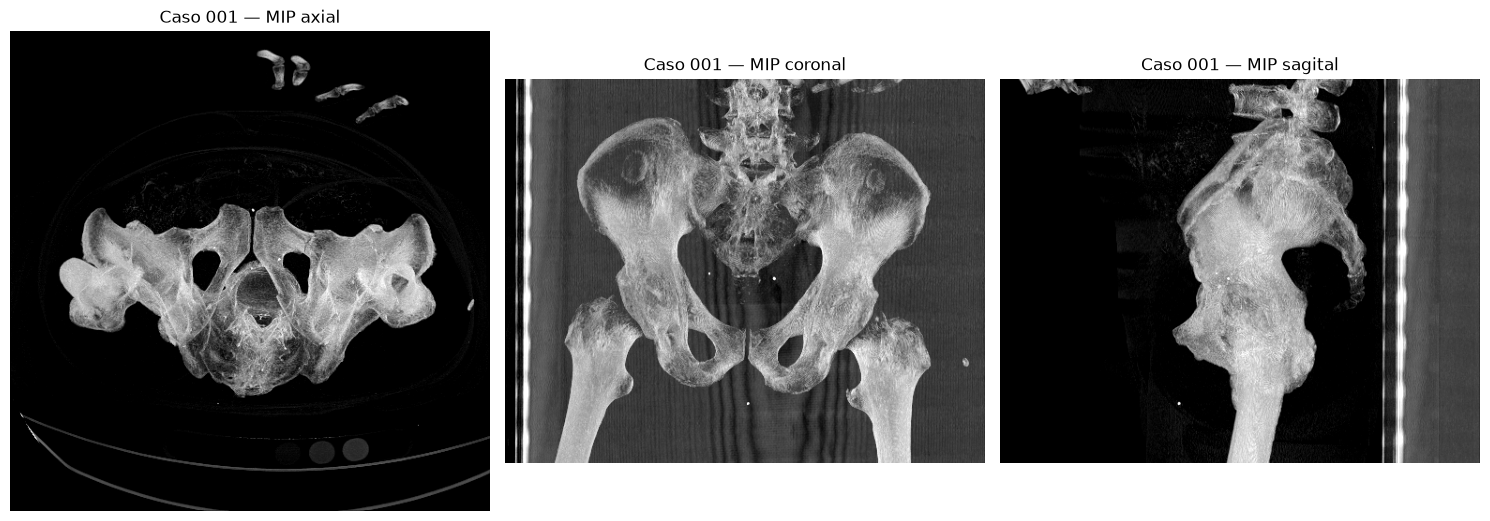

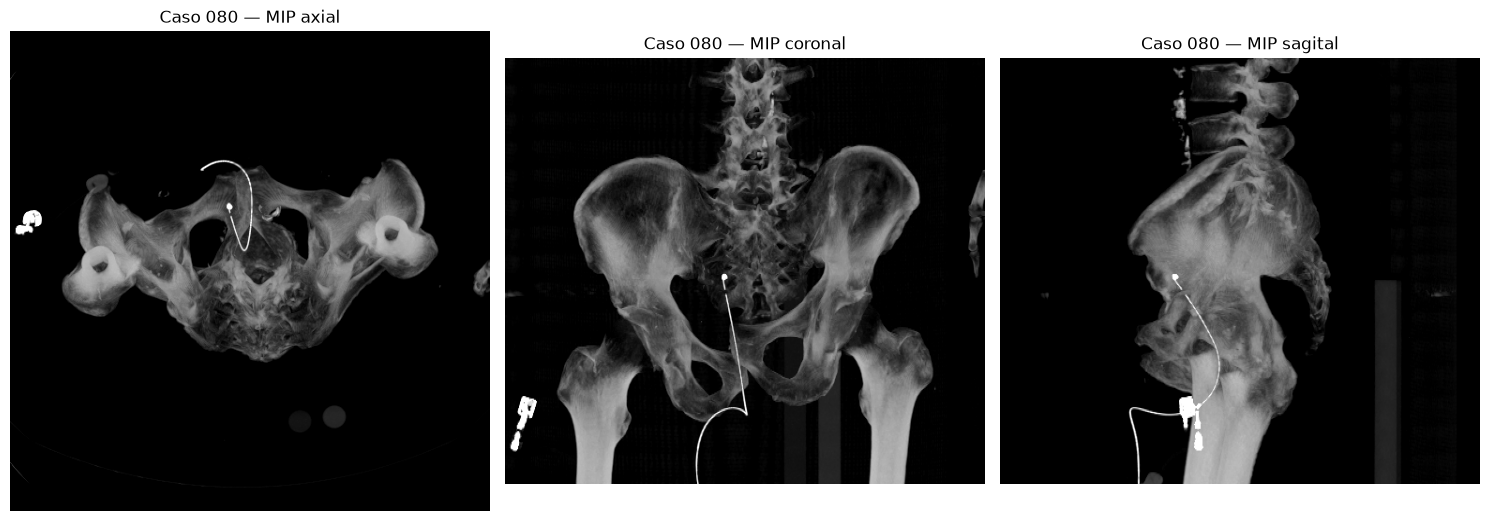

In [23]:
from mip_visualizer import compute_mip, HU_THRESHOLD

def mostrar_mip(case_id, vmax=2000):
    img = sitk.ReadImage(str(find_image_path(case_id)))
    vol = sitk.GetArrayFromImage(img)
    sx, sy, sz = img.GetSpacing()
    vistas = [("axial", 0, sy / sx, "upper"), ("coronal", 1, sz / sx, "lower"), ("sagital", 2, sz / sy, "lower")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
    for ax, (nombre, eje, aspecto, origen) in zip(axes, vistas):
        ax.imshow(compute_mip(vol, eje, HU_THRESHOLD), cmap="gray", vmin=HU_THRESHOLD, vmax=vmax, aspect=aspecto, origin=origen)
        ax.set_title(f"Caso {case_id} — MIP {nombre}"); ax.axis("off")
    plt.tight_layout(); plt.show()

for cid in CASOS[:2]:
    mostrar_mip(cid)

## 7. Estado de la semana 8
- [x] Dataset curado con splits fijos
- [x] Pipeline de carga `.mha` + ventaneo HU
- [x] EDA de fragmentos por caso
- [x] Visualizador 1 (MIP raw)
- [x] EDA de intensidades (endurecimiento de haz y desajuste de histograma) → `02_eda_intensidades.ipynb`